# Dependency imports

In [1]:
import torch
from torchvision.models import convnext_base, ConvNeXt_Base_Weights

from Training.library import validate
from Training.training import Config, TrainingResources, initClassifierTrainers, trainingLoop
import Training.metrics as m
import Training.plotting as plots

# Pretrained ConvNeXt-B specific configuration

In [2]:
c = Config("ConvNeXt-B")

#Configure execution to needs
c.purge    = False #Nincs nyúlka!

#c.training = False #ezt tanításhoz raktam
c.loadBest = False

#Set hyperparams to model
c.learningRate = 2e-6
c.weightDecay  = 1e-8

#c.numClasses = 8
c.batchSize = 16
c.workers = 16


# Initialize resources

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
#device = "cpu"
print(f"Using {device} device")

model = convnext_base(weights=ConvNeXt_Base_Weights)
model.classifier[2] = torch.nn.Linear(model.classifier[2].in_features, out_features=c.numClasses)

TR = TrainingResources(c, model, initClassifierTrainers, device)
TR.load(c)

print(TR.criterion)
print(TR.optimizer)

#Note: After this point only some config changes will apply

Using cuda device


/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded state
CrossEntropyLoss()
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 2e-06
    maximize: False
    weight_decay: 1e-08
)


# Execute training

In [4]:
# Override training related config if neccesary
c.training = False
c.gpuSleep = 30
c.trainingEpochs = 70

trainingLoop(c, TR, stopAt=0)

Training turned off


In [5]:
display(TR.history)

,epoch,train_loss,train_acc,val_loss,val_acc,cm_true_Actinic keratoses_pred_Actinic keratoses,cm_true_Basal cell carcinoma_pred_Actinic keratoses,cm_true_Benign keratosis-like lesions_pred_Actinic keratoses,cm_true_Dermatofibroma_pred_Actinic keratoses,cm_true_Melanocytic nevi_pred_Actinic keratoses,cm_true_Melanoma_pred_Actinic keratoses,cm_true_Squamous cell carcinoma_pred_Actinic keratoses,cm_true_Vascular lesions_pred_Actinic keratoses,cm_true_Actinic keratoses_pred_Basal cell carcinoma,cm_true_Basal cell carcinoma_pred_Basal cell carcinoma,cm_true_Benign keratosis-like lesions_pred_Basal cell carcinoma,cm_true_Dermatofibroma_pred_Basal cell carcinoma,cm_true_Melanocytic nevi_pred_Basal cell carcinoma,cm_true_Melanoma_pred_Basal cell carcinoma,cm_true_Squamous cell carcinoma_pred_Basal cell carcinoma,cm_true_Vascular lesions_pred_Basal cell carcinoma,cm_true_Actinic keratoses_pred_Benign keratosis-like lesions,cm_true_Basal cell carcinoma_pred_Benign keratosis-like lesions,cm_true_Benign keratosis-like lesions_pred_Benign keratosis-like lesions,cm_true_Dermatofibroma_pred_Benign keratosis-like lesions,cm_true_Melanocytic nevi_pred_Benign keratosis-like lesions,cm_true_Melanoma_pred_Benign keratosis-like lesions,cm_true_Squamous cell carcinoma_pred_Benign keratosis-like lesions,cm_true_Vascular lesions_pred_Benign keratosis-like lesions,cm_true_Actinic keratoses_pred_Dermatofibroma,cm_true_Basal cell carcinoma_pred_Dermatofibroma,cm_true_Benign keratosis-like lesions_pred_Dermatofibroma,cm_true_Dermatofibroma_pred_Dermatofibroma,cm_true_Melanocytic nevi_pred_Dermatofibroma,cm_true_Melanoma_pred_Dermatofibroma,cm_true_Squamous cell carcinoma_pred_Dermatofibroma,cm_true_Vascular lesions_pred_Dermatofibroma,cm_true_Actinic keratoses_pred_Melanocytic nevi,cm_true_Basal cell carcinoma_pred_Melanocytic nevi,cm_true_Benign keratosis-like lesions_pred_Melanocytic nevi,cm_true_Dermatofibroma_pred_Melanocytic nevi,cm_true_Melanocytic nevi_pred_Melanocytic nevi,cm_true_Melanoma_pred_Melanocytic nevi,cm_true_Squamous cell carcinoma_pred_Melanocytic nevi,cm_true_Vascular lesions_pred_Melanocytic nevi,cm_true_Actinic keratoses_pred_Melanoma,cm_true_Basal cell carcinoma_pred_Melanoma,cm_true_Benign keratosis-like lesions_pred_Melanoma,cm_true_Dermatofibroma_pred_Melanoma,cm_true_Melanocytic nevi_pred_Melanoma,cm_true_Melanoma_pred_Melanoma,cm_true_Squamous cell carcinoma_pred_Melanoma,cm_true_Vascular lesions_pred_Melanoma,cm_true_Actinic keratoses_pred_Squamous cell carcinoma,cm_true_Basal cell carcinoma_pred_Squamous cell carcinoma,cm_true_Benign keratosis-like lesions_pred_Squamous cell carcinoma,cm_true_Dermatofibroma_pred_Squamous cell carcinoma,cm_true_Melanocytic nevi_pred_Squamous cell carcinoma,cm_true_Melanoma_pred_Squamous cell carcinoma,cm_true_Squamous cell carcinoma_pred_Squamous cell carcinoma,cm_true_Vascular lesions_pred_Squamous cell carcinoma,cm_true_Actinic keratoses_pred_Vascular lesions,cm_true_Basal cell carcinoma_pred_Vascular lesions,cm_true_Benign keratosis-like lesions_pred_Vascular lesions,cm_true_Dermatofibroma_pred_Vascular lesions,cm_true_Melanocytic nevi_pred_Vascular lesions,cm_true_Melanoma_pred_Vascular lesions,cm_true_Squamous cell carcinoma_pred_Vascular lesions,cm_true_Vascular lesions_pred_Vascular lesions
0,1,1.922992,0.433718,1.503834,0.602610,23,18,18,0,9,8,4,0,51,225,85,7,110,69,41,11,5,26,45,2,34,27,6,3,0,0,0,0,0,0,0,0,0,40,61,13,992,115,8,5,7,19,49,1,141,231,1,0,0,3,3,0,0,2,2,0,0,1,1,0,1,0,0,6
1,2,1.635190,0.588589,1.185731,0.644919,29,25,24,0,9,11,4,0,42,242,50,6,76,43,36,7,7,18,64,3,46,24,5,0,0,0,3,4,2,1,0,1,0,16,49,6,1004,107,6,0,7,26,62,2,139,263,3,0,1,4,6,1,2,2,8,0,0,1,4,1,9,1,0,17
2,3,1.428174,0.612279,1.054886,0.661131,47,50,31,1,17,14,9,0,25,220,37,5,51,28,25,3,9,19,84,3,53,31,6,0,0,2,6,4,10,4,1,1,0,11,46,5,1018,106,3,0,5,19,51,1,124,265,5,0,0,6,3,1,0,1,13,0,0,5,4,3,14,3,0,21
3,4,1.293909,0.633008,1.017085,0.655200,53,50,28,1,14,11,9,0,15,208,25,2,44,18,15,2,11,17,110,1,71,41,7,0,0,8,9,

# Plots of learning process

Bestval at epoch: 62


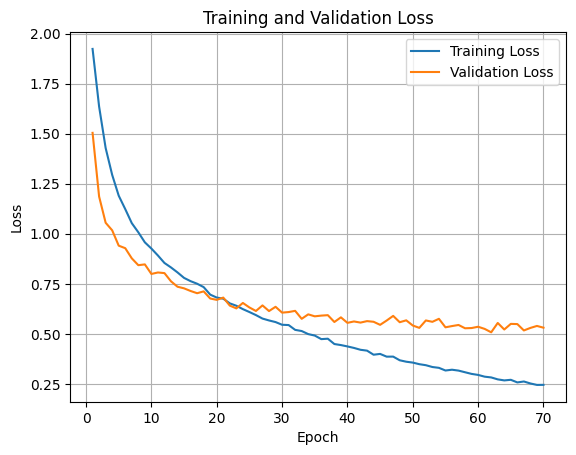

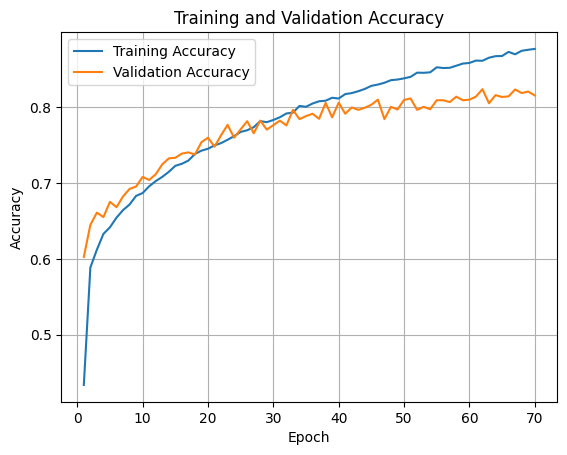

In [6]:
value = TR.history.loc[TR.history["val_acc"].idxmax(), "epoch"]
print(f"Bestval at epoch: {value}")

plots.plotTraining(TR.history, TR.plotsFolder)

# Metrics of best model on test data

### Evaluate on test set

In [7]:
#Reload weights with best validation
c.loadBest = True

TR.load(c)

#Evaluate on test set
test_loss, test_acc, CM = validate(TR.model, TR.test_loader, TR.criterion, device)

print(f"Test loss: {test_loss} \t | Test acc: {test_acc}")

Loaded state
Test loss: 0.5428934930640412 	 | Test acc: 0.7996062992125984


### Plots of test results

,accuracy,precision,recall,f1
Actinic keratoses,97.09,56.73,67.05,61.46
Basal cell carcinoma,95.87,82.39,87.09,84.67
Benign keratosis-like lesions,93.07,64.36,74.14,68.90
Dermatofibroma,99.57,75.00,84.00,79.25
Melanocytic nevi,87.83,92.45,82.76,87.34
Melanoma,88.54,66.27,72.85,69.40
Squamous cell carcinoma,98.35,65.71,71.88,68.66
Vascular lesions,99.61,75.00,92.31,82.76


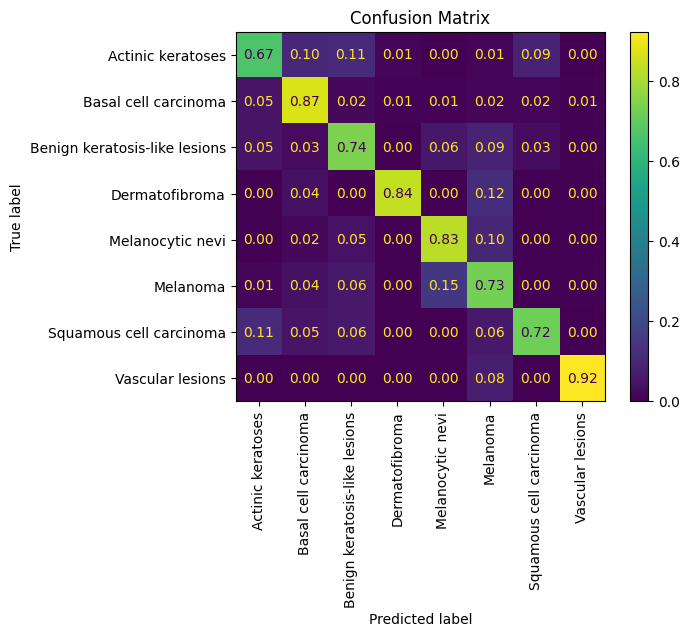

,Actinic keratoses,Basal cell carcinoma,Benign keratosis-like lesions,Dermatofibroma,Melanocytic nevi,Melanoma,Squamous cell carcinoma,Vascular lesions
Actinic keratoses,59,16,13,0,4,5,7,0
Basal cell carcinoma,9,290,7,1,24,18,3,0
Benign keratosis-like lesions,10,7,195,0,59,28,4,0
Dermatofibroma,1,3,0,21,2,1,0,0
Melanocytic nevi,0,3,16,0,1066,68,0,0
Melanoma,1,6,23,3,129,330,4,2
Squamous cell carcinoma,8,6,8,0,1,1,46,0
Vascular lesions,0,2,1,0,3,2,0,24


In [8]:
metrics = plots.deriveMetrics(CM, TR.plotsFolder)
display(metrics)
plots.plotConfusionMatrix(CM, TR.plotsFolder)
display(CM)

Best Melanoma validation @ epoch 67.0


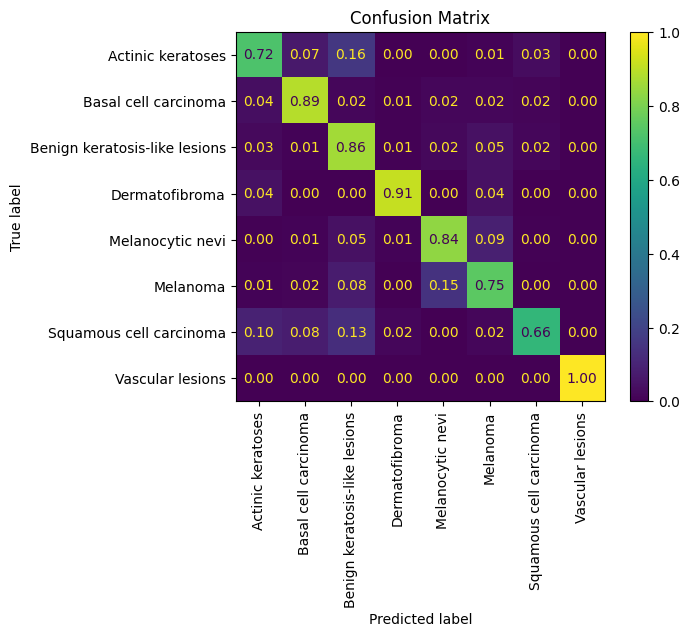

accuracy     90.11
precision    71.31
recall       74.78
f1           73.00
Name: Melanoma, dtype: float64

In [9]:
score = plots.bestMelanoma(TR)
display(score)